**Part 3. AI Agent 심화 프로젝트**

- Chapter 02. 추천시스템 Agent

    - **📒[실습]** Clip 02. 추천시스템 Agent (1)🗒️

### 사용자 메모리(State)를 활용하기

: 사용자 취향을 기반으로 추천하는 시스템


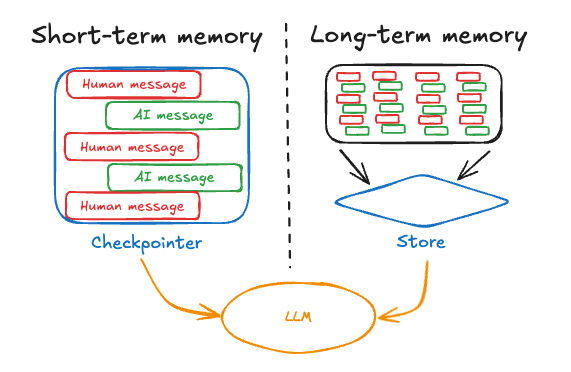

In [1]:
import getpass
import os


def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("OPENAI_API_KEY")

In [2]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4o")

#### 🔧 사용자의 정보를 도구로 호출하는 법

~~`InjectedState` : 모델로부터 생성되지 않도록 설정~~

**[+ 2026.03.17 코드 변경사항]**

> langchain v1 으로 변경됨에 따라 기존의 langgraph 사전구축 에이전트인 create_react_agent 대신 langchain.agents 의 create_agent를 사용합니다.

> langchain v1 으로 변경됨에 따라 기존의 InjectedState 에서 **ToolRuntime**(도구 실행 시점의 모든 런타임 정보를 통합적으로 제공하는 객체)을 사용합니다.

--- 

`ToolRuntime`은 랭체인의 v0 버전의 InjectedState, InjectedStore, get_runtime, InjectedToolCallId로 사용했던 개별 주입 방식을 하나로 통합한 것입니다. 

`ToolRunTime`을 사용하면 다음의 구성 요소를 인식할 수 있습니다.
- State(상태): 그래프의 현재 상태
- Tool Call ID(도구 호출 ID): 도구 호출ID

In [23]:
from typing import Annotated
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent, AgentState

class CustomState(AgentState):
    user_id: str

def get_user_info(
    runtime: ToolRuntime
) -> str:
    """Look up user info."""
    user_id = runtime.state["user_id"]
    return "User is John Smith" if user_id == "user_123" else "Unknown user"

agent = create_agent(
    model=model,
    tools=[get_user_info],
    state_schema=CustomState,
)

In [24]:
response = agent.invoke({
    "messages": "look up user information",
    "user_id": "user_123"
})

In [25]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

look up user information
================================== Ai Message ==================================
Tool Calls:
  get_user_info (call_OCiOCvELwf6dx3tn2H5PvbJp)
 Call ID: call_OCiOCvELwf6dx3tn2H5PvbJp
  Args:
================================= Tool Message =================================
Name: get_user_info

User is John Smith
================================== Ai Message ==================================

The user information indicates that the user is John Smith.


#### 1️⃣ 사용자의 기본 정보를 기반으로 추천하기 (Short Memory)

In [22]:
class InfoState(AgentState):
    user_id: str
    user_sex: str
    user_age: int

- user 기본 정보 (이름, 성별, 나이)

**[+ 2026.03.17 코드 변경사항]**

> langchain v1 으로 변경됨에 따라 기존의 `state: Annotated[InfoState, InjectedState]` 대신 `runtime: ToolRuntime`를 사용합니다.

In [26]:
def get_user_info(
    runtime: ToolRuntime
) -> str:
    """Look up user info."""
    user_id = runtime.state["user_id"]
    user_sex = runtime.state["user_sex"]
    user_age = runtime.state["user_age"]
    return "User Info: " + user_id + ", " + user_sex + ", " + str(user_age)

In [27]:
agent = create_agent(
    model=model,
    tools=[get_user_info],
    state_schema=InfoState,
)

response = agent.invoke({
    "messages": "사용자 기본 정보를 기반으로 영화 추천해주세요.",
    "user_id": "user_123",
    "user_sex": "female",
    "user_age": 25,
})

In [28]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

사용자 기본 정보를 기반으로 영화 추천해주세요.
================================== Ai Message ==================================
Tool Calls:
  get_user_info (call_hz3zNymFUIq8SOpIRE6Vforn)
 Call ID: call_hz3zNymFUIq8SOpIRE6Vforn
  Args:
================================= Tool Message =================================
Name: get_user_info

User Info: user_123, female, 25
================================== Ai Message ==================================

영화 추천을 위해, 다음과 같은 정보를 기반으로 추천해드리겠습니다: 25세의 여성 사용자입니다.

**추천 영화**:

1. **라라랜드 (La La Land, 2016)** - 음악과 사랑, 꿈에 관한 이야기로 감성적인 요소가 많은 영화입니다.
   
2. **그랜드 부다페스트 호텔 (The Grand Budapest Hotel, 2014)** - 독특한 유머와 비주얼을 가진 영화로, 여러 연령대에서 사랑받는 작품입니다.
   
3. **어바웃 타임 (About Time, 2013)** - 로맨스와 시간 여행을 소재로 한 따뜻한 영화로, 감동적인 이야기를 좋아하는 분들께 추천합니다.
   
4. **위대한 개츠비 (The Great Gatsby, 2013)** - 화려한 비주얼과 드라마틱한 스토리를 가진, 1920년대의 미국을 배경으로 한 영화입니다.
   
5. **비긴 어게인 (Begin Again, 2013)** - 음악 중심의 영화로, 삶의 새로운 

#### 2️⃣ 사용자의 축적된 취향을 기반으로 추천하기 (Long Memory)


In [29]:
from langgraph.store.memory import InMemoryStore

store = InMemoryStore()

store.put(
    ("users",),
    "user_123",
    {
        "user_name": "mina",
        "user_sex": "female",
        "user_age": 25,
    }
)

In [30]:
from langchain_core.runnables import RunnableConfig
from langgraph.config import get_store

def get_user_info(config: RunnableConfig) -> str:
    """Look up user info."""
    store = get_store()
    user_id = config["configurable"].get("user_id")

    user_info = store.get(("users",), user_id)
    return str(user_info.value) if user_info else "Unknown user"


def save_user_info(
    likes: list[str] = None,
    dislikes: list[str] = None,
    current_watch: list[str] = None,
    config: RunnableConfig = None
) -> str:
    """Save user preference information to the store.

    Args:
        likes: List of movie titles or genres the user likes
        dislikes: List of movie titles or genres the user dislikes
        current_watch: List of movies the user has recently watched
        config: RunnableConfig with user_id

    When a user mentions a movie they've watched (e.g., "I recently watched La La Land"),
    add it to current_watch. When they express liking a movie or genre, add it to likes.
    When they express disliking something, add it to dislikes.
    """
    store = get_store()
    user_id = config["configurable"].get("user_id")

    # Retrieve existing user data from the store
    user_info = store.get(("users",), user_id)
    if user_info:
        user_data = user_info.value
    else:
        user_data = {}

    # Initialize user_data if it doesn't exist
    if likes:
        if "likes" not in user_data:
            user_data["likes"] = []
        user_data["likes"].extend(likes)

    if dislikes:
        if "dislikes" not in user_data:
            user_data["dislikes"] = []
        user_data["dislikes"].extend(dislikes)

    if current_watch:
        if "current_watch" not in user_data:
            user_data["current_watch"] = []
        user_data["current_watch"].extend(current_watch)

    # Save updated user data back to the store
    store.put(("users",), user_id, user_data)
    return f"User preferences updated successfully: added {len(likes or [])} likes, {len(dislikes or [])} dislikes, and {len(current_watch or [])} watched movies."

**[+ 2026.03.17 코드 변경사항]**

> langchain v1 으로 변경됨에 따라 create_agent 의 파라미터 prompt 대신 system_prompt 로 변경하였습니다.

In [32]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

agent = create_agent(
    model=model,
    tools=[get_user_info, save_user_info],
    store=store,
    system_prompt= """
        You are a helpful movie recommendation assistant that can look up user information based on a user ID.
        Use the user's preferences—such as liked and disliked genres or watch history—to recommend movies they might enjoy.

        Do not mention the user's personal information (e.g., age, sex, user ID) directly in your responses.

        If preference information is missing, base your recommendations on basic user information such as age and sex.

        IMPORTANT: Only use `save_user_info` when users EXPLICITLY state their preferences or watch history.
        Do NOT save information when:
        - Users merely ask about a movie
        - Users ask if a movie is good or worth watching
        - Users mention a movie title as an example
        - Users are just discussing or inquiring about movies

        ONLY save information when:
        - Users clearly state they have watched a specific movie (e.g., "I watched La La Land recently", "나 얼마 전에 라라랜드 봤어")
        - Users express clear preference about a genre or movie (e.g., "I love action movies", "난 공포영화 싫어해")
        - Users directly share their opinions on movies they've seen (e.g., "I didn't like The Godfather", "인셉션은 정말 좋았어")

        Correct examples:
        - If they say "I watched La La Land recently" - call save_user_info with current_watch=["La La Land"]
        - If they say "I love action movies" - call save_user_info with likes=["action"]
        - If they say "I didn't like The Godfather" - call save_user_info with dislikes=["The Godfather"]

        Incorrect examples (DO NOT save these):
        - If they ask "Is Begin Again good?" - DO NOT save anything
        - If they ask "What do you think about horror movies?" - DO NOT save anything
        - If they ask "비긴 어게인 어떨까?" - DO NOT save anything
        - However, you may use the get_user_info tool to check the user's basic and preference information for assistance.

        If you need more details to make a better recommendation, ask warm, casual questions (e.g., "요즘 어떤 장르가 끌려요?" or "최근에 재밌게 본 영화 있어요?").

        Just naturally incorporate user information into your tone and movie choices.
        Keep your responses concise, helpful, and easy to understand.
        """,
    checkpointer=checkpointer,
)

In [33]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["q", "exit", "quit"]:
        break

    response = agent.invoke(
        {"messages": [{"role": "user", "content": user_input}]},
        config={"configurable": {"user_id": "user_123", "thread_id": "1"}}
    )

    for msg in response["messages"]:
        msg.pretty_print()

================================ Human Message =================================

영화 추천해줘
================================== Ai Message ==================================
Tool Calls:
  get_user_info (call_eIHOZwPsfrClIfTIM21wfdC2)
 Call ID: call_eIHOZwPsfrClIfTIM21wfdC2
  Args:
================================= Tool Message =================================
Name: get_user_info

{'user_name': 'mina', 'user_sex': 'female', 'user_age': 25}
================================== Ai Message ==================================

25세 여성분께서는 다양한 장르를 즐기실 것 같아요. 최근에 재밌게 본 영화나 끌리고 있는 장르가 있다면 알려주시면 더욱 맞춤형 추천을 드릴 수 있어요. 아니면, 로맨스나 드라마를 좋아하신다면 **"라라 랜드"**나 **"콜 미 바이 유어 네임"**과 같은 영화는 어떠세요? 또, 액션을 원하신다면 **"매드 맥스: 분노의 도로"**도 추천드리고 싶네요.
================================ Human Message =================================

영화 추천해줘
================================== Ai Message ==================================
Tool Calls:
  get_user_info (call_eIHOZwPsfrClIfTIM21wfdC2)
 Call ID: call_eIHOZwPsfrClIfTIM21wfdC2
  Args:

In [34]:
store.get(("users",), "user_123").value

{'user_name': 'mina',
 'user_sex': 'female',
 'user_age': 25,
 'current_watch': ['La La Land'],
 'likes': ['disaster']}